In [4]:
import pandas as pd
import numpy as np

# Import data set and then partition

exclude valence from spotify features to prevent leakeage

In [57]:
df = pd.read_csv("output.csv", index_col=0)
y = df[["valence_tags", "dominance_tags", "arousal_tags"]]
X = df.select_dtypes(include='number').drop(columns=["valence_tags", "dominance_tags", "arousal_tags", "time_signature", "valence"])

In [58]:
FEATURE_COLS = X.columns
X.isna().sum()

popularity                0
duration_ms               0
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
tempo                     0
number_of_emotion_tags    0
dtype: int64

In [59]:
y.isna().sum()

valence_tags      0
dominance_tags    0
arousal_tags      0
dtype: int64

# Modelling


## clustering

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize structures to keep track of results for each value of k
kmeans_labels = {}
kmean_scores = {}

for k in range(2, 15):
  print("Clustering with", str(k), "clusters")

  # Fit the clusters
  kmeans = KMeans(n_clusters=k, max_iter=300, random_state=67)
  labels = kmeans.fit_predict(y)

  # Save the results
  kmeans_labels[k] = labels
  kmean_scores[k] = silhouette_score(y, labels)

Clustering with 2 clusters
Clustering with 3 clusters
Clustering with 4 clusters
Clustering with 5 clusters
Clustering with 6 clusters
Clustering with 7 clusters
Clustering with 8 clusters
Clustering with 9 clusters
Clustering with 10 clusters
Clustering with 11 clusters


Clustering with 12 clusters
Clustering with 13 clusters
Clustering with 14 clusters


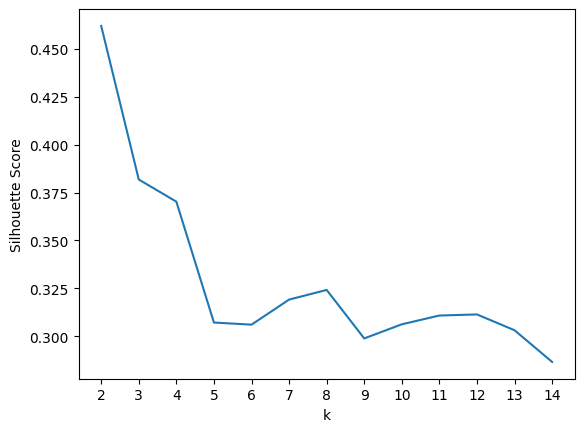

In [61]:

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Plot the silhouette scores as a function of k
plt.plot(range(2,15), kmean_scores.values())
plt.xticks(range(2,15))
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

In [62]:
y.loc[:, "8_clusters"] = kmeans_labels[8]
y.loc[:, "4_clusters"] = kmeans_labels[4]

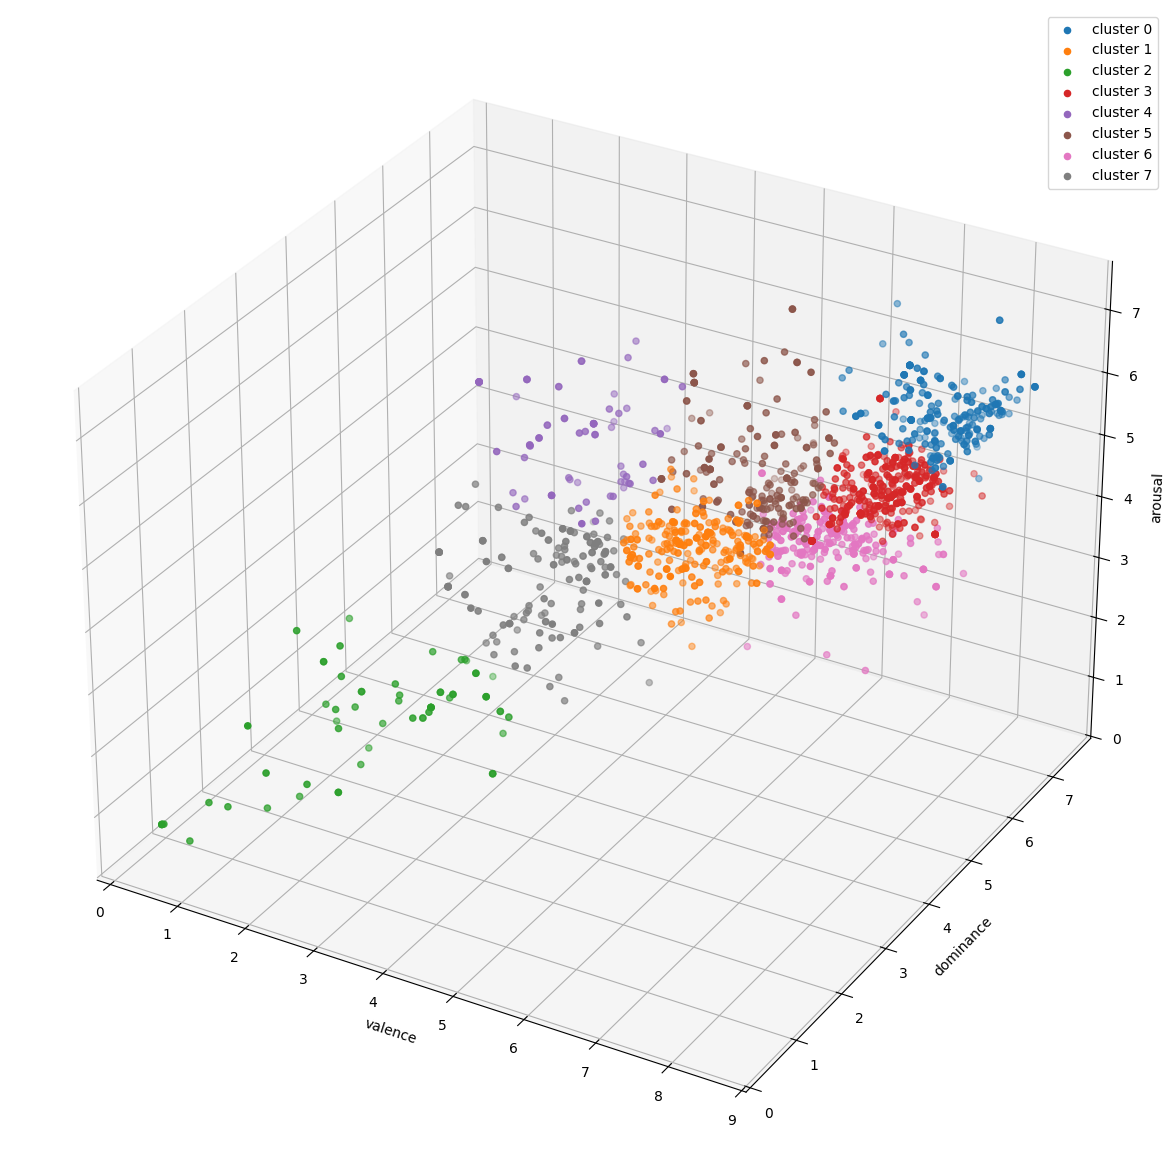

In [63]:
# 3d scatterplot using matplotlib

fig = plt.figure(figsize = (15,15))
ax = fig.add_subplot(111, projection='3d')
# ax.scatter(x[y_clusters == 0,0],x[y_clusters == 0,1],x[y_clusters == 0,2], s = 40 , color = 'blue', label = "cluster 0")
# ax.scatter(x[y_clusters == 1,0],x[y_clusters == 1,1],x[y_clusters == 1,2], s = 40 , color = 'orange', label = "cluster 1")
# ax.scatter(x[y_clusters == 2,0],x[y_clusters == 2,1],x[y_clusters == 2,2], s = 40 , color = 'green', label = "cluster 2")
# ax.scatter(x[y_clusters == 3,0],x[y_clusters == 3,1],x[y_clusters == 3,2], s = 40 , color = '#D12B60', label = "cluster 3")
# ax.scatter(x[y_clusters == 4,0],x[y_clusters == 4,1],x[y_clusters == 4,2], s = 40 , color = 'purple', label = "cluster 4")
for group in range(8):
    drawing_data = y[kmeans_labels[8] == group].to_numpy().T
    ax.scatter(drawing_data[0], drawing_data[1], drawing_data[2], label=f"cluster {group}")

ax.set_xlabel('valence')
ax.set_ylabel('dominance')
ax.set_zlabel('arousal')
ax.legend()
plt.show()

In [64]:
import plotly.express as px

fig = px.scatter_3d(y, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='8_clusters')
fig.show()

In [65]:
import plotly.express as px

fig = px.scatter_3d(y, x='valence_tags', y='dominance_tags', z='arousal_tags',
              color='4_clusters')
fig.show()

We can see that it matches previous EDA discovery that there is a strong linear correlation between valence and dominance. Overall, the data seem to distribute around a 3D plane.

## Classification

In [66]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
CV = KFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # avoid test leakage

scaler_full = StandardScaler()
X = scaler_full.fit_transform(X)

training_set = [X_train, y_train, X_test, y_test]


In [ ]:

def cv_classification_report(model, X, y, cv, label):
    '''
    Run stratified K-fold cross-validation for a classifier and report results.

    Parameters
    ----------
    model  : sklearn estimator
    X      : feature matrix
    y      : encoded target array (integer labels)
    cv     : StratifiedKFold instance
    label  : string name for display / dict key

    Returns
    -------
    results : dict with keys label, acc_mean, acc_std, f1_mean, f1_std
    '''
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    # Macro-F1 treats all classes equally regardless of support
    f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

    acc_mean, acc_std = acc_scores.mean(), acc_scores.std()
    f1_mean,  f1_std  = f1_scores.mean(),  f1_scores.std()
    
    
    labels = ['accuracy', 'f1_scores']
    colors = ['peachpuff', 'orange']

    fig, ax = plt.subplots()

    bplot = ax.boxplot([acc_scores, f1_scores],
                    patch_artist=True,  # fill with color
                    tick_labels=labels)  # will be used to label x-ticks

    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    plt.show()

    print(f"[{label}]")
    print(f"  CV Accuracy : {acc_mean:.4f} +/- {acc_std:.4f}")
    print(f"  CV F1-macro : {f1_mean:.4f} +/- {f1_std:.4f}")
    print()

    return {
        'label'   : label,
        'acc_mean': acc_mean,
        'acc_std' : acc_std,
        'f1_mean' : f1_mean,
        'f1_std'  : f1_std,
    }

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
def confusion_matrix(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train[['4_clusters']])
    y_preds = model.predict(X_test)
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test['4_clusters'],
        cmap=plt.cm.Blues,
    )
    disp.ax_.set_title(f'confusion matrix for {name} classifier')
    

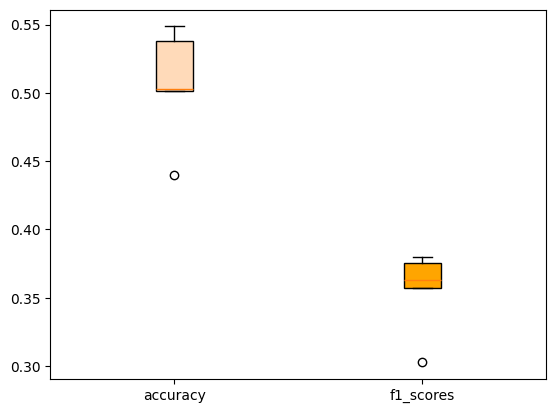

[Logistic Regression Baseline]
  CV Accuracy : 0.5062 +/- 0.0382
  CV F1-macro : 0.3557 +/- 0.0278



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


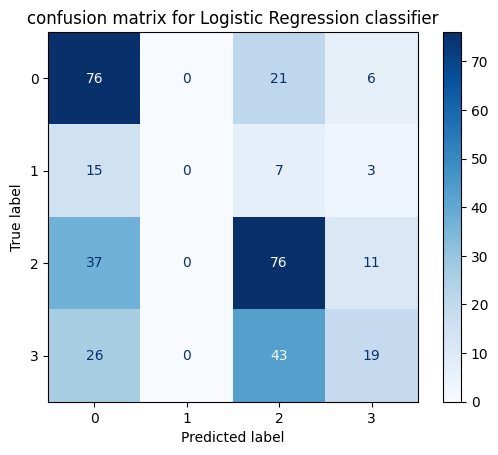

In [77]:
lr_baseline = LogisticRegression(
    max_iter=1500,
    solver='lbfgs',
    random_state=42
)

results_lr_baseline = cv_classification_report(
    lr_baseline, X, y['4_clusters'], CV, label='Logistic Regression Baseline'
)

confusion_matrix(lr_baseline, *training_set, "Logistic Regression")


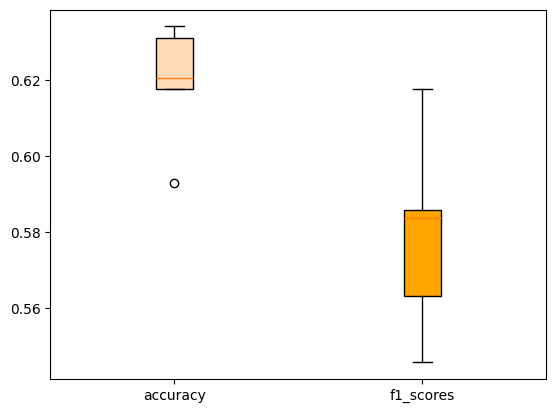

[Decision Tree]
  CV Accuracy : 0.6193 +/- 0.0146
  CV F1-macro : 0.5793 +/- 0.0241



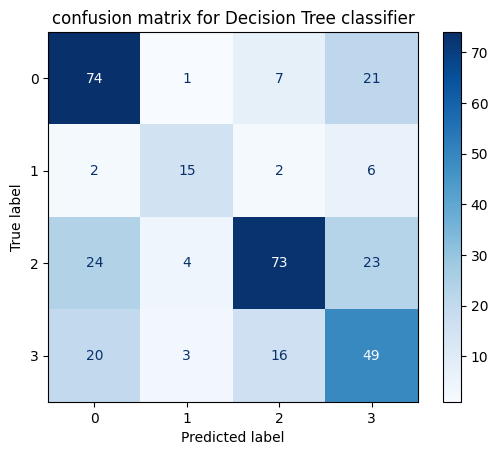

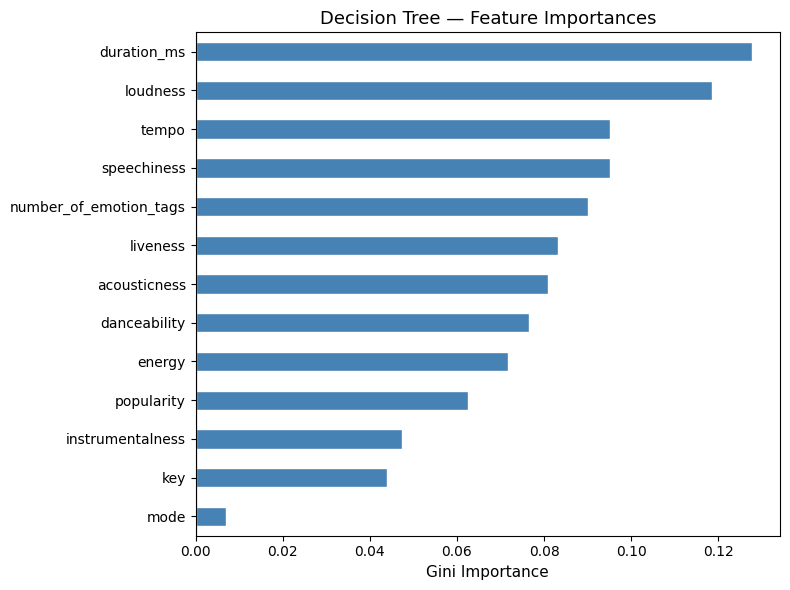

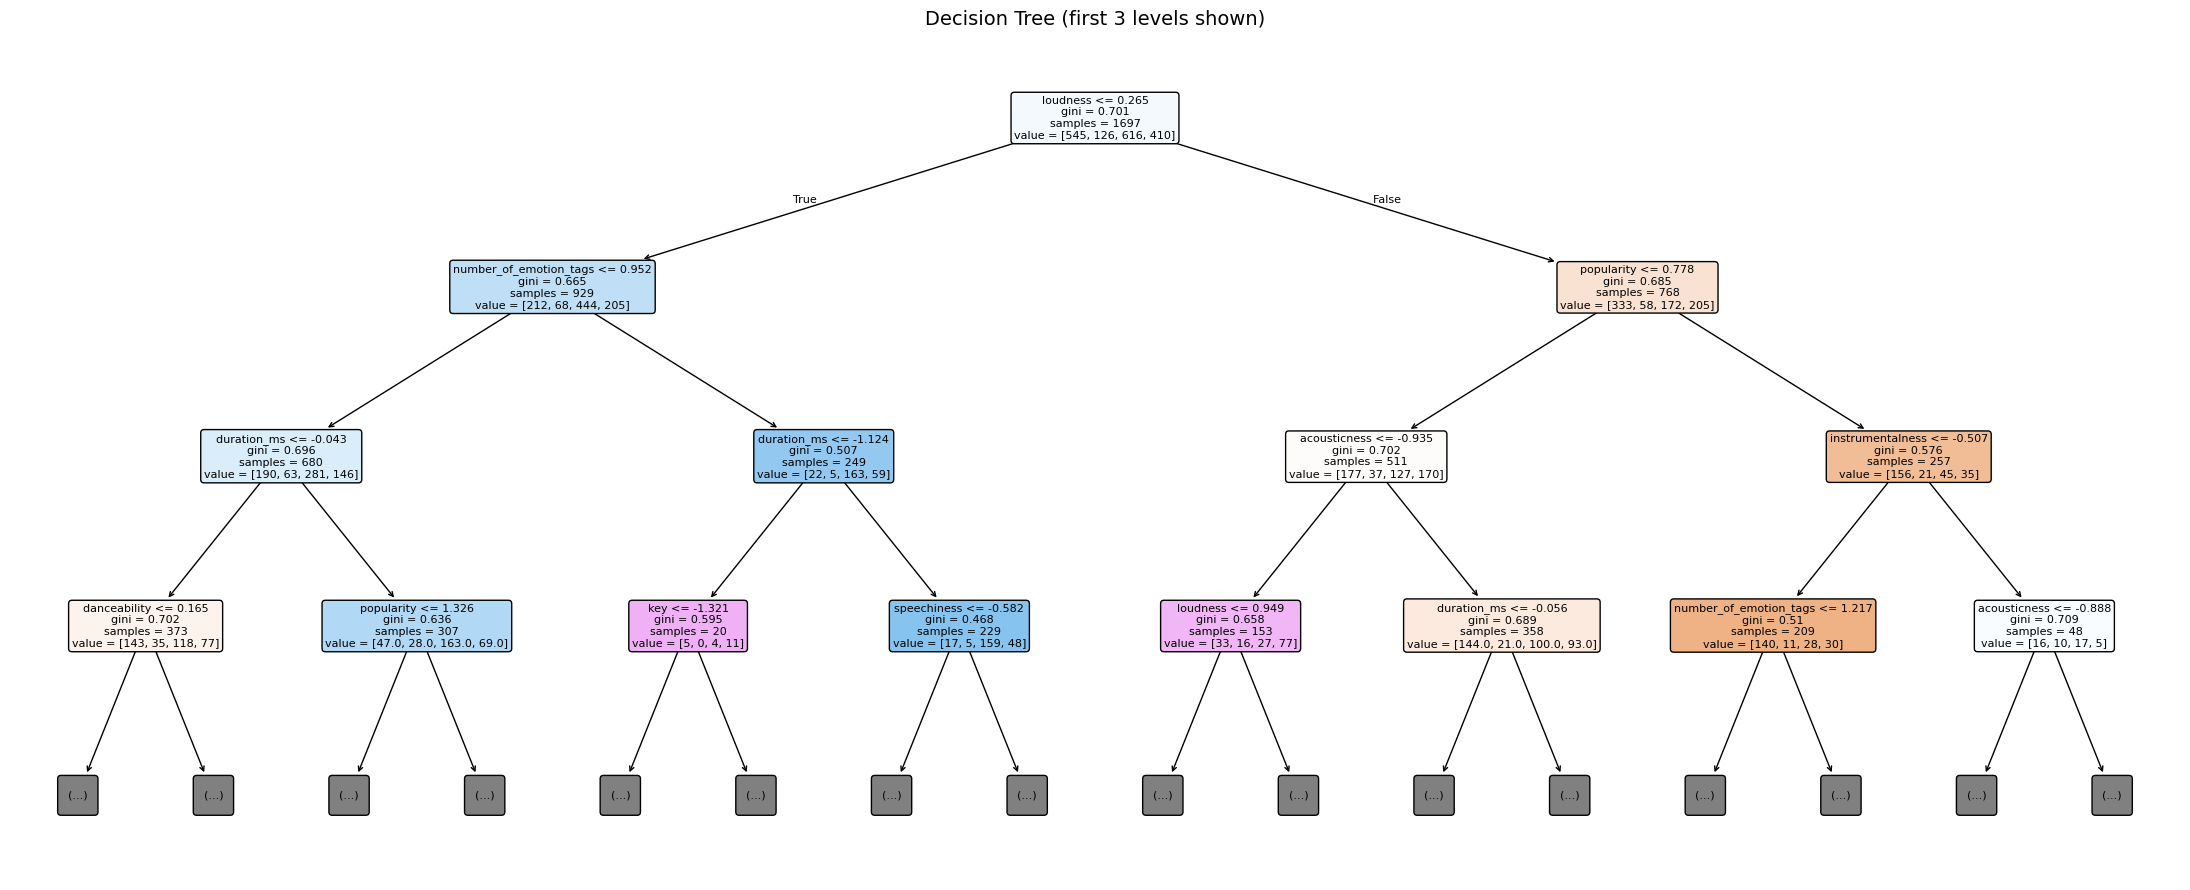

What the tree learned about arousal:
  Top 2 splitting features: ['duration_ms', 'loudness', 'tempo']
  The tree partitions songs primarily on these acoustic cues,
  suggesting they are most discriminative for arousal level.



In [78]:
# decision tree


dt = DecisionTreeClassifier(random_state=42)

results_dt = cv_classification_report(
    dt, X, y['4_clusters'], CV, label='Decision Tree'
)

confusion_matrix(dt, *training_set, "Decision Tree")

dt.fit(X, y['4_clusters'])

# ---- Feature importance bar chart ---
fi_dt = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi_dt.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Decision Tree — Feature Importances', fontsize=13)
ax.set_xlabel('Gini Importance', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('c4_dt_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Tree visualisation (limited to depth=3 for readability) ---
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    max_depth=3,
    feature_names=FEATURE_COLS,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (first 3 levels shown)', fontsize=14)
plt.tight_layout()
plt.savefig('c4_dt_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

top_dt = fi_dt.sort_values(ascending=False).head(3).index.tolist()
print("What the tree learned about arousal:")
print(f"  Top 2 splitting features: {top_dt}")
print("  The tree partitions songs primarily on these acoustic cues,")
print("  suggesting they are most discriminative for arousal level.\n")

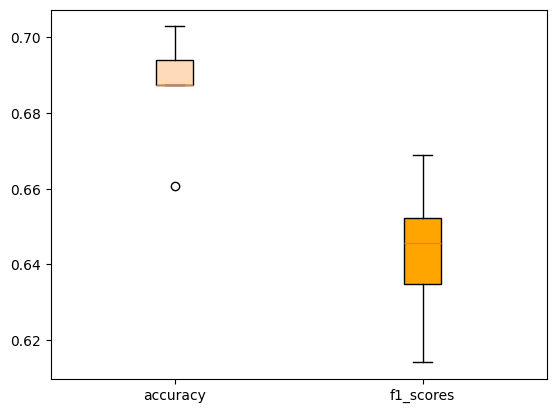

[Random Forest]
  CV Accuracy : 0.6865 +/- 0.0141
  CV F1-macro : 0.6431 +/- 0.0183



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


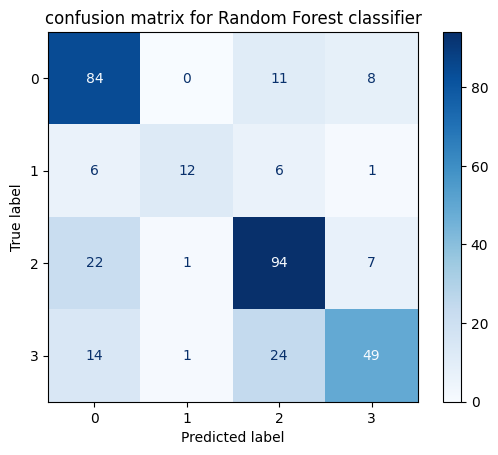

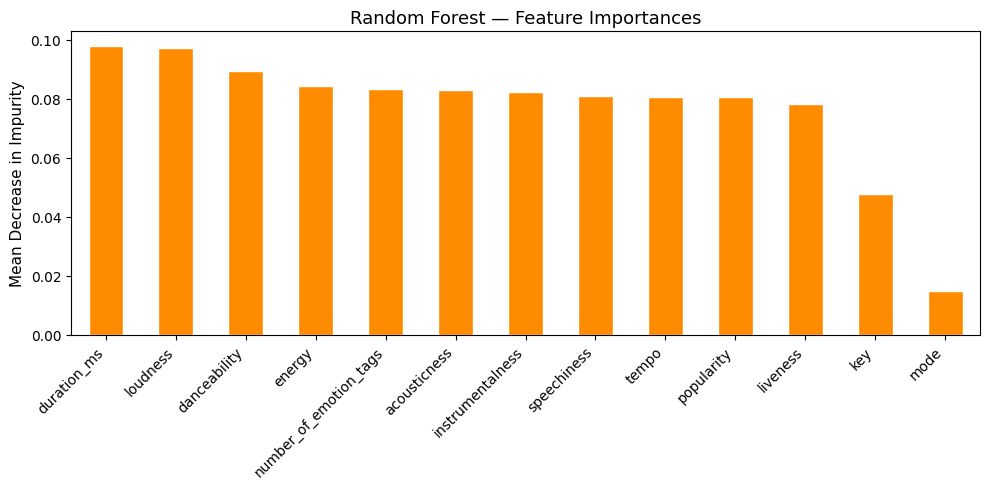

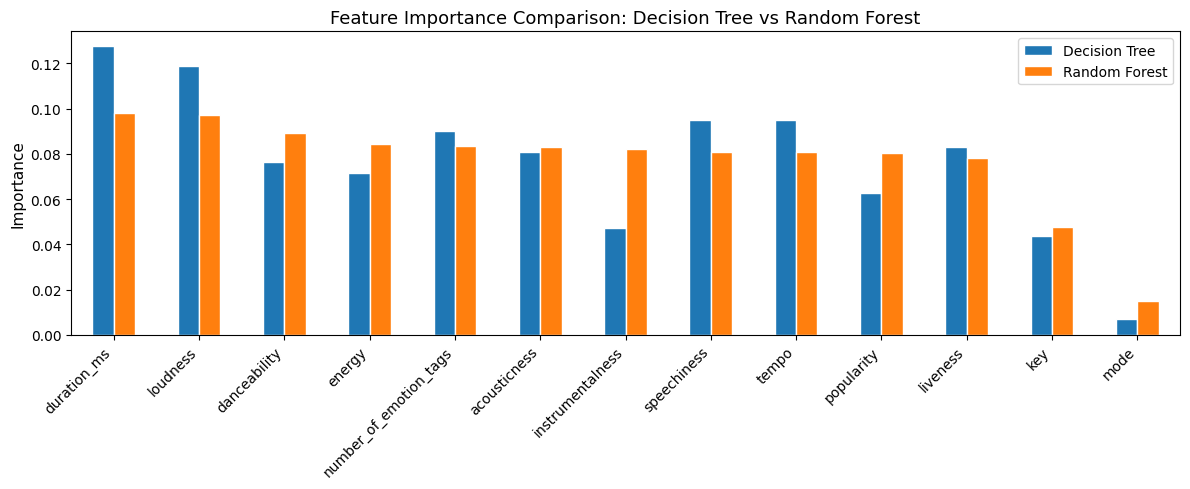

Bias-Variance note:
  A single decision tree has low bias but high variance — small data
  perturbations can drastically change which splits are chosen.
  Random Forest averages 100 de-correlated trees (bagging + feature
  subsampling), reducing variance while accepting a slight bias increase.
  This typically yields better generalisation (higher CV scores).



In [79]:
# RANDOM FOREST (ENSEMBLE)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

results_rf = cv_classification_report(
    rf, X, y['4_clusters'], CV, label='Random Forest'
)

confusion_matrix(rf, *training_set, "Random Forest")

rf.fit(X, y['4_clusters'])

fi_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi_rf.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_ylabel('Mean Decrease in Impurity', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('c5_rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Comparison with Decision Tree importances ---
compare_fi = pd.DataFrame({
    'Decision Tree': pd.Series(dt.feature_importances_,  index=FEATURE_COLS),
    'Random Forest': pd.Series(rf.feature_importances_, index=FEATURE_COLS),
}).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
compare_fi.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', fontsize=13)
ax.set_ylabel('Importance', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('c5_dt_vs_rf_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bias-Variance note:")
print("  A single decision tree has low bias but high variance — small data")
print("  perturbations can drastically change which splits are chosen.")
print("  Random Forest averages 100 de-correlated trees (bagging + feature")
print("  subsampling), reducing variance while accepting a slight bias increase.")
print("  This typically yields better generalisation (higher CV scores).\n")

=== C6: Shallow Neural Network (MLPClassifier) ===



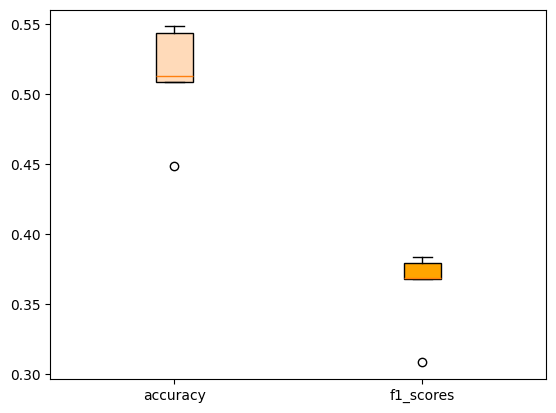

[MPL (0)]
  CV Accuracy : 0.5127 +/- 0.0359
  CV F1-macro : 0.3614 +/- 0.0272



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


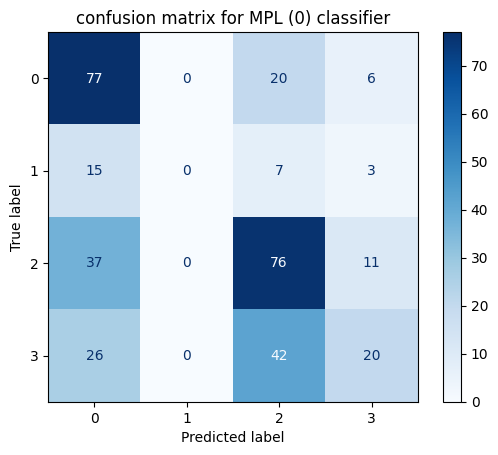

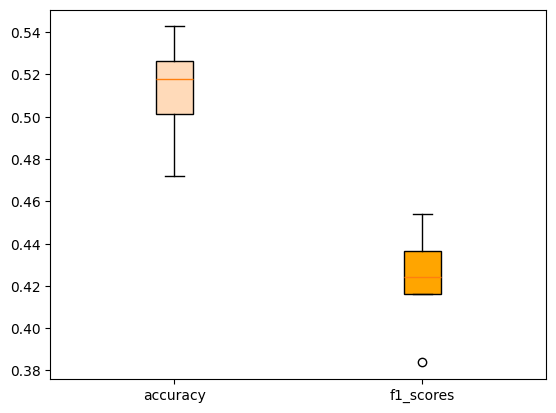

[MPL (16)]
  CV Accuracy : 0.5121 +/- 0.0241
  CV F1-macro : 0.4229 +/- 0.0233



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.

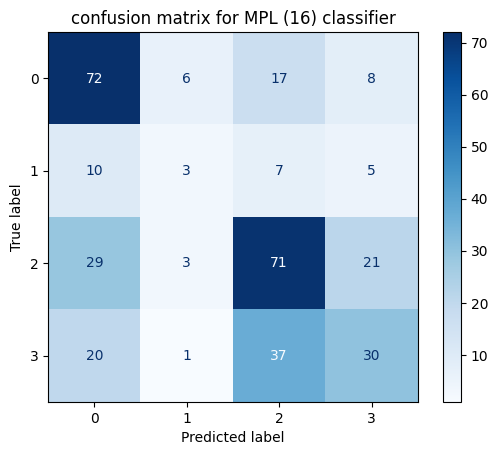

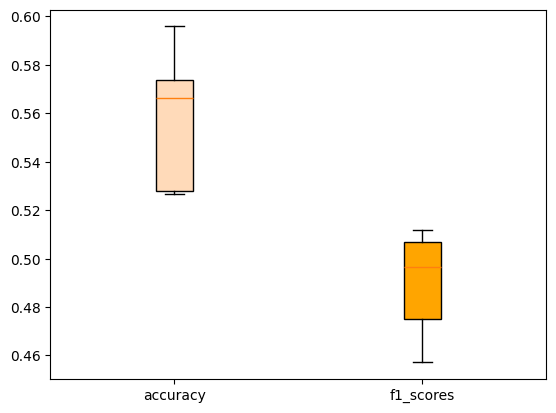

[MLP (32, 8)]
  CV Accuracy : 0.5581 +/- 0.0270
  CV F1-macro : 0.4894 +/- 0.0205



/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Comparison with simpler models:
  LR Baseline accuracy : 0.5062
  Decision Tree accuracy: 0.6193
  Random Forest accuracy: 0.6865
  MLP (16,) accuracy   : 0.5121
  MLP (32,8) accuracy  : 0.5581
  Neural networks can model non-linear interactions but offer less
  interpretability than logistic regression or decision trees.



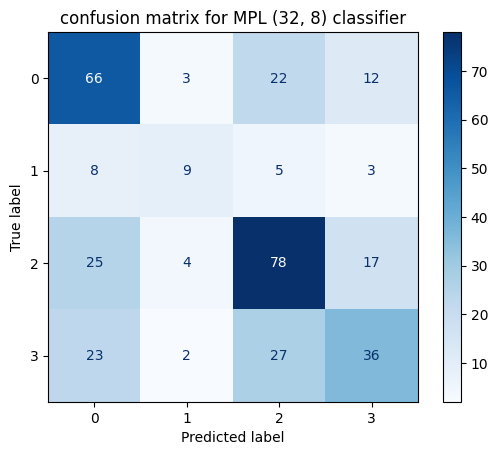

In [ ]:
# SHALLOW NEURAL NETWORK (MLPClassifier)


mlp_0 = MLPClassifier(
    hidden_layer_sizes=(),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_0 = cv_classification_report(
    mlp_0, X, y['4_clusters'], CV, label='MPL (0)'
)

confusion_matrix(mlp_0, *training_set, "MPL (0)")

mlp_16 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_16 = cv_classification_report(
    mlp_16, X, y['4_clusters'], CV, label='MPL (16)'
)

confusion_matrix(mlp_16, *training_set, "MPL (16)")

mlp_32_8 = MLPClassifier(
    hidden_layer_sizes=(32, 8),
    activation='relu',
    max_iter=1500,
    random_state=42
)

results_mlp_32_8 = cv_classification_report(
    mlp_32_8, X, y['4_clusters'], CV, label='MLP (32, 8)'
)
confusion_matrix(mlp_32_8, *training_set, "MPL (32, 8)")


print("Comparison with simpler models:")
print(f"  LR Baseline accuracy : {results_lr_baseline['acc_mean']:.4f}")
print(f"  Decision Tree accuracy: {results_dt['acc_mean']:.4f}")
print(f"  Random Forest accuracy: {results_rf['acc_mean']:.4f}")
print(f"  MLP (16,) accuracy   : {results_mlp_16['acc_mean']:.4f}")
print(f"  MLP (32,8) accuracy  : {results_mlp_32_8['acc_mean']:.4f}")
print("  Neural networks can model non-linear interactions but offer less")
print("  interpretability than logistic regression or decision trees.\n")

In [88]:
all_results = [
    results_lr_baseline,
    results_dt,
    results_rf,
    results_mlp_0,
    results_mlp_16,
    results_mlp_32_8,
]

comparison_data = []
for r in all_results:
    comparison_data.append({
        'Model'                  : r['label'],
        'CV Accuracy (mean+/-std)' : f"{r['acc_mean']:.4f} +/- {r['acc_std']:.4f}",
        'CV F1-macro (mean+/-std)' : f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}",
        '_acc'                   : r['acc_mean'],
        '_f1'                    : r['f1_mean'],
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('_acc', ascending=False)

display_cols = ['Model', 'CV Accuracy (mean+/-std)', 'CV F1-macro (mean+/-std)']
comparison_display = comparison_df[display_cols].reset_index(drop=True)

try:
    from IPython.display import display
    styled = (
        comparison_display.style
        .set_caption("Classifier Comparison — 5-Fold Stratified CV")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('background-color', '#4C72B0'), ('color', 'white')]},
        ])
    )
    display(styled)
except Exception:
    print(comparison_display.to_string(index=False))

best_row = comparison_df.loc[comparison_df['_acc'].idxmax()]
print(f"\nBest model by CV Accuracy: {best_row['Model']}")

                       Model CV Accuracy (mean+/-std) CV F1-macro (mean+/-std)
               Random Forest        0.6865 +/- 0.0141        0.6431 +/- 0.0183
               Decision Tree        0.6193 +/- 0.0146        0.5793 +/- 0.0241
                 MLP (32, 8)        0.5581 +/- 0.0270        0.4894 +/- 0.0205
                     MPL (0)        0.5127 +/- 0.0359        0.3614 +/- 0.0272
                    MPL (16)        0.5121 +/- 0.0241        0.4229 +/- 0.0233
Logistic Regression Baseline        0.5062 +/- 0.0382        0.3557 +/- 0.0278

Best model by CV Accuracy: Random Forest


## Regression

In [95]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score
TARGETS = ["valence_tags", "arousal_tags", "dominance_tags"]

results_store = {}

def cv_regression_report(model, X, y_reg, cv, label):
    '''
    Run 5-fold CV for each regression target and report per-target and
    overall-average MSE and R2.

    Parameters
    ----------
    model   : sklearn estimator (single-output; called once per target)
    X       : feature matrix (numpy array or DataFrame)
    y_reg   : DataFrame with columns valence_tags, arousal_tags, dominance_tags
    cv      : cross-validation splitter (e.g. the shared KFold instance)
    label   : string identifier used in result storage and printing

    Returns
    -------
    record  : dict with "label", per-target MSE/R2, and "avg_mse"/"avg_r2"
    '''
    per_target_mse = {}
    per_target_r2  = {}

    print(f"\n{'='*60}")
    print(f"  Cross-Validation Report — {label}")
    print(f"{'='*60}")

    for target in TARGETS:
        y_col = y_reg[target].values  # 1-D array for this target

        neg_mse_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
        r2_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="r2"
        )

        mean_mse = -neg_mse_scores.mean()
        mean_r2  =  r2_scores.mean()

        per_target_mse[target] = mean_mse
        per_target_r2[target]  = mean_r2

        print(f"  {target:<22}  CV MSE = {mean_mse:.4f}   CV R2 = {mean_r2:.4f}")

    avg_mse = np.mean(list(per_target_mse.values()))
    avg_r2  = np.mean(list(per_target_r2.values()))
    print(f"  {'[AVERAGE]':<22}  CV MSE = {avg_mse:.4f}   CV R2 = {avg_r2:.4f}")
    print(f"{'='*60}")

    record = {"label": label, "avg_mse": avg_mse, "avg_r2": avg_r2}
    for t in TARGETS:
        record[f"mse_{t}"] = per_target_mse[t]
        record[f"r2_{t}"]  = per_target_r2[t]

    results_store[label] = record
    return record


  Cross-Validation Report — Linear Regression
  valence_tags            CV MSE = 2.2418   CV R2 = 0.0675
  arousal_tags            CV MSE = 0.9939   CV R2 = 0.1456
  dominance_tags          CV MSE = 1.1218   CV R2 = 0.0639
  [AVERAGE]               CV MSE = 1.4525   CV R2 = 0.0924


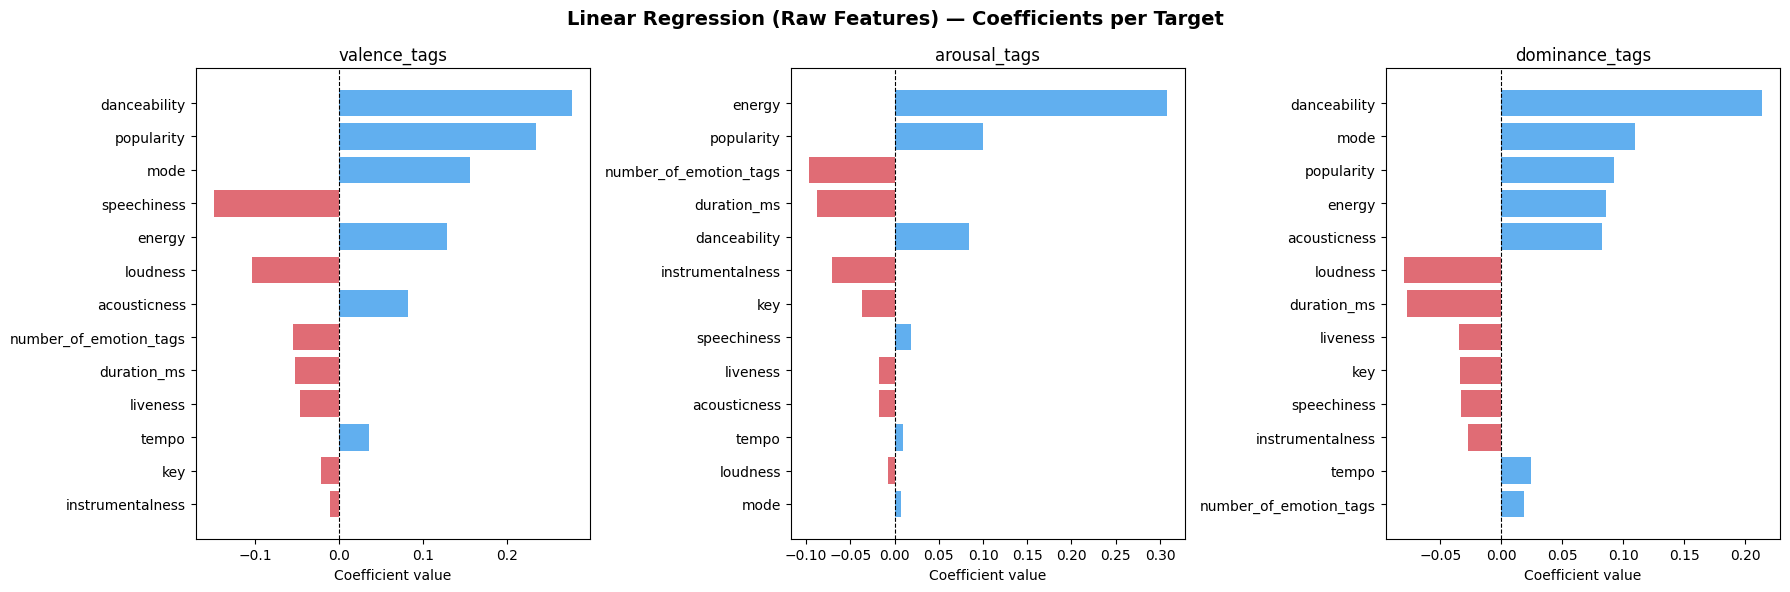


Top-3 most important features by |coefficient| — Raw Linear Regression
------------------------------------------------------------

  valence_tags:
    1. danceability                 coef = +0.2771  (positive)
    2. popularity                   coef = +0.2348  (positive)
    3. mode                         coef = +0.1559  (positive)

  arousal_tags:
    1. energy                       coef = +0.3080  (positive)
    2. popularity                   coef = +0.0999  (positive)
    3. number_of_emotion_tags       coef = -0.0972  (negative)

  dominance_tags:
    1. danceability                 coef = +0.2138  (positive)
    2. mode                         coef = +0.1096  (positive)
    3. popularity                   coef = +0.0926  (positive)


In [98]:
lr_base = LinearRegression()

# 5-fold CV evaluation
lr_base_record = cv_regression_report(
    lr_base, X, y, CV,
    label="Linear Regression"
)

# ---- Fit on full data to extract coefficients for interpretability ----------
lr_base_fitted_coefs = {}
for target in TARGETS:
    lr_base.fit(X, y[target].values)
    lr_base_fitted_coefs[target] = lr_base.coef_.copy()

# ---- Plot: horizontal bar charts, one subplot per target -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Linear Regression (Raw Features) — Coefficients per Target",
    fontsize=14, fontweight="bold"
)

for ax, target in zip(axes, TARGETS):
    coefs  = lr_base_fitted_coefs[target]
    order           = np.argsort(np.abs(coefs))
    sorted_features = np.array(FEATURE_COLS)[order]
    sorted_coefs    = coefs[order]
    colors = ["#e06c75" if c < 0 else "#61afef" for c in sorted_coefs]
    ax.barh(sorted_features, sorted_coefs, color=colors)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(target, fontsize=12)
    ax.set_xlabel("Coefficient value")

plt.tight_layout()
plt.savefig("./figures/r2_lr_base_coefficients.svg", dpi=120, bbox_inches="tight")
plt.show()

print("\nTop-3 most important features by |coefficient| — Raw Linear Regression")
print("-" * 60)
for target in TARGETS:
    coefs   = lr_base_fitted_coefs[target]
    top_idx = np.argsort(np.abs(coefs))[::-1][:3]
    print(f"\n  {target}:")
    for rank, idx in enumerate(top_idx, 1):
        direction = "positive" if coefs[idx] > 0 else "negative"
        print(
            f"    {rank}. {FEATURE_COLS[idx]:<28} "
            f"coef = {coefs[idx]:+.4f}  ({direction})"
        )


Since features are standardized, the coefficient directly represent relative importance.

### Random forest regressor


  Cross-Validation Report — Random Forest Regressor
  valence_tags            CV MSE = 1.4320   CV R2 = 0.3999
  arousal_tags            CV MSE = 0.6689   CV R2 = 0.4205
  dominance_tags          CV MSE = 0.7838   CV R2 = 0.3469
  [AVERAGE]               CV MSE = 0.9616   CV R2 = 0.3891


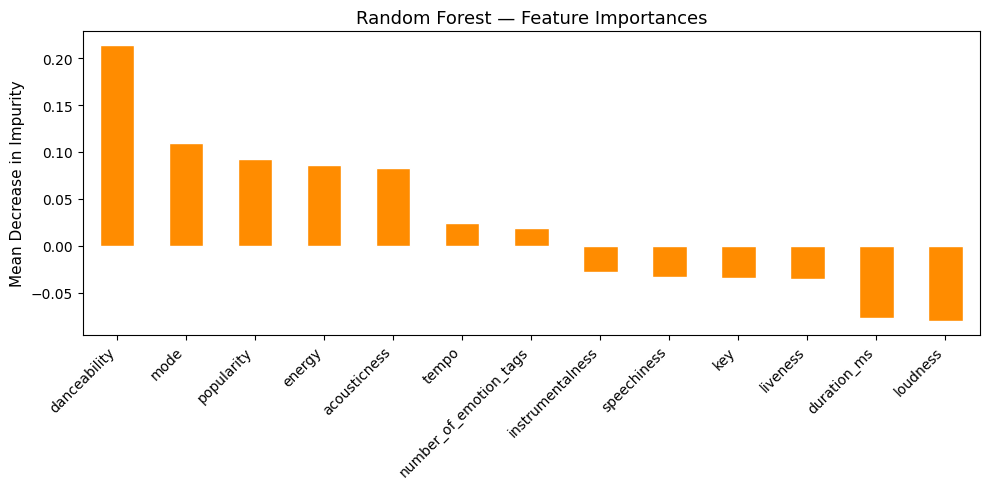

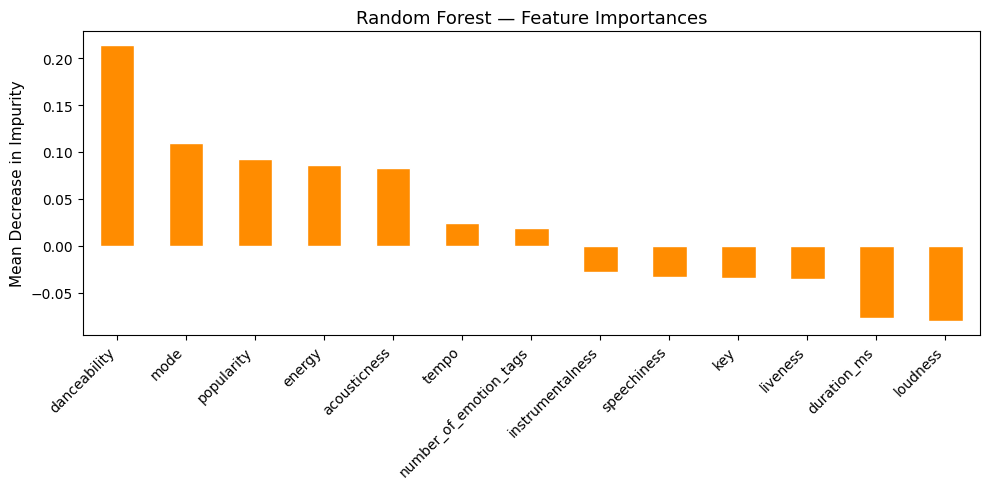

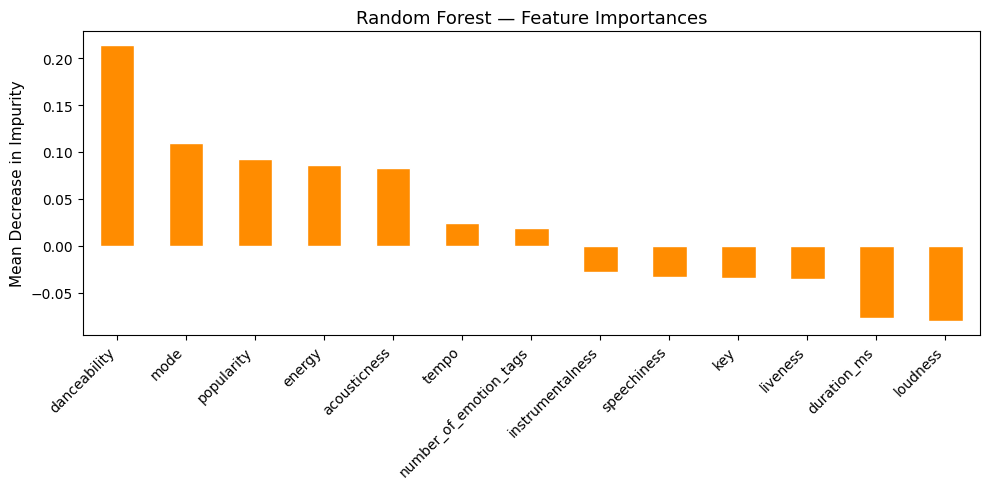

In [101]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(100,)
# 5-fold CV evaluation
rfr_record = cv_regression_report(
    rfr, X, y, CV,
    label="Random Forest Regressor"
)

# ---- Fit on full data to extract coefficients for interpretability ----------
rfr_feature_importances = {}
for target in TARGETS:
    rfr.fit(X, y[target].values)
    rfr_feature_importances[target] = lr_base.coef_.copy()

    fi_rf = pd.Series(rfr_feature_importances[target], index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    fi_rf.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title('Random Forest — Feature Importances', fontsize=13)
    ax.set_ylabel('Mean Decrease in Impurity', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('c5_rf_feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()


### Shallow neural net regressor
  ()      — no hidden layer, architecturally equivalent to linear regression, used here as a baseline.
  (16,)   — one hidden layer of 16 sigmoid units; minimal capacity, quick to train.
  (32, 8) — two hidden layers; first layer detects feature combinations,
             second layer compresses them toward the output.

  Early stopping is used to prevent overfitting on this
  modest dataset (~1,200 samples).

  Interpretability trade-off: unlike linear coefficients, individual weights
  in the hidden layers have no direct semantic meaning.

In [ ]:

mlp_archs = {
    "MLP ()": MLPRegressor(
        hidden_layer_sizes=(),
        activation="logistic",
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    
    "MLP (16,)": MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="logistic",
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    "MLP (32, 8)": MLPRegressor(
        hidden_layer_sizes=(32, 8),
        max_iter=2000,
        activation="logistic",
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
}



  Cross-Validation Report — MLP ()


/home/jthu/miniforge3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  valence_tags            CV MSE = 2.2551   CV R2 = -0.6862


In [ ]:

for arch_label, mlp_model in mlp_archs.items():
    cv_regression_report(
        mlp_model, X, y, CV,
        label=arch_label
    )

# ---- Bar chart: average CV MSE for all regression models so far ------------
comparison_labels = [
    "Linear Regression",
    "Random Forest Regressor",
    "MLP ()",
    "MLP (16,)",
    "MLP (32, 8)",
]
avg_mses = [results_store[lbl]["avg_mse"] for lbl in comparison_labels]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#abb2bf", "#61afef", "#e5c07b", "#98c379", "#c678dd"]
bars   = ax.barh(comparison_labels, avg_mses, color=colors, edgecolor="white")
ax.set_xlabel("Mean CV MSE (average across 3 emotion targets)")
ax.set_title(
    "Regression Models — CV MSE Comparison\n(5-fold CV, Log-Transformed & Scaled Features where applicable)",
    fontsize=12, fontweight="bold"
)
ax.axvline(
    results_store["LR — Raw Features"]["avg_mse"],
    color="grey", linestyle="--", linewidth=1,
    label="Raw-feature LR baseline"
)
ax.legend(fontsize=9)

for bar, val in zip(bars, avg_mses):
    ax.text(
        val + 0.005, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("r5_mlp_regression_comparison.png", dpi=120, bbox_inches="tight")
plt.show()